# Easy Slider Setup

I'm still working on the models but want to get started on the frontend.

So to start with I'm going to try using the values from Google's Expressive Tags
and organizing them into the relations i want. Then scoring each font based on their real metrics made by humans.

Rather than having a model attempt to classify these values which I'm still working on improving.

In [1]:
import pandas as pd
import os

In [2]:
gt_df = pd.read_csv("tags/expressive_tags.csv")

In [3]:
gt_df

,font,Active,Artistic,Awkward,Business,Calm,Childlike,Competent,Cute,Excited,...,Futuristic,Happy,Innovative,Loud,Playful,Rugged,Sincere,Sophisticated,Stiff,Vintage
0,42dot Sans,0.0,0.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ABeeZee,10.0,0.0,0.0,75.0,91.6,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ADLaM Display,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AR One Sans,5.0,0.0,0.0,75.0,90.6,0.0,68.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Abel,10.0,0.0,0.0,0.0,83.4,0.0,19.0,0.0,0.0,...,10.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,Zeyada,20.0,71.0,55.0,0.0,0.0,64.0,0.0,0.0,0.0,...,0.0,30.0,0.0,10.0,34.0,0.0,97.0,0.0,0.0,0.0
1897,Zhi Mang Xing,67.0,67.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,...,0.0,25.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0
1898,Zilla Slab,0.0,0.0,0.0,88.5,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,0.0,40.0,0.0,0.0,0.0,0.0,72.0,28.0
1899,Zilla Slab Highlight,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,12.0,20.0,0.0,0.0,0.0,0.0,10.0,0.0


In [4]:
gt_df.columns[0:]

Index(['font', 'Active', 'Artistic', 'Awkward', 'Business', 'Calm',
       'Childlike', 'Competent', 'Cute', 'Excited', 'Fancy', 'Futuristic',
       'Happy', 'Innovative', 'Loud', 'Playful', 'Rugged', 'Sincere',
       'Sophisticated', 'Stiff', 'Vintage'],
      dtype='str')

In [5]:
gt_df.index

RangeIndex(start=0, stop=1901, step=1)

From these categories we need rankings from 0 to 1 for:

Formality = Buisness + Competent + Sophisticated - Playful - Childlike - Cute
Energy = Excited + Loud + Active - Calm - Sophisticated - Stiff
Age = Futuristic + Innovative - Vintage - Fancy
Warmth = Happy + Sincere + Cute + Playful - Stiff - Futuristic
Expressiveness = Artistic + Awkward - Business - Stiff

Finally standardize these values on a 0 to 100 scale

In [6]:
def compute_semantic_axes(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame(index=df.index)
    result['font'] = df['font']

    result['formality'] = (
        df['Business'] + df['Competent'] + df['Sophisticated']
        - df['Playful'] - df['Childlike'] - df['Cute']
    )
    result['energy'] = (
        df['Excited'] + df['Loud'] + df['Active']
        - df['Calm'] - df['Sophisticated'] - df['Stiff']
    )
    result['age'] = (
        df['Futuristic'] + df['Innovative']
        - df['Vintage'] - df['Fancy']
    )
    result['warmth'] = (
        df['Happy'] + df['Sincere'] + df['Cute'] + df['Playful']
        - df['Stiff'] - df['Futuristic']
    )
    result['expressiveness'] = (
        df['Artistic'] + df['Awkward']
        - df['Business'] - df['Stiff'] - df['Calm']
    )
    # Min-max scale each axis to [0, 100]
    for col in result.columns[1:]:
        col_min = result[col].min()
        col_max = result[col].max()
        result[col] = (result[col] - col_min) / (col_max - col_min) * 100

    return result

In [7]:
semantic_scores = compute_semantic_axes(gt_df)

In [10]:
semantic_scores

,font,formality,energy,age,warmth,expressiveness
0,42dot Sans,75.589574,48.118719,50.636132,37.754497,43.559719
1,ABeeZee,75.589574,29.048843,50.636132,38.742835,22.107728
2,ADLaM Display,60.074472,46.950222,50.636132,37.754497,61.124122
3,AR One Sans,89.656599,28.114045,50.636132,37.754497,22.341920
4,Abel,64.004965,28.628184,53.180662,35.777822,41.592506
...,...,...,...,...,...,...
1896,Zeyada,39.801407,45.781725,50.636132,69.578968,90.632319
1897,Zhi Mang Xing,55.316508,66.113578,50.636132,47.242538,76.814988
1898,Zilla Slab,78.382292,31.292358,43.511450,27.475786,23.536300
1899,Zilla Slab Highlight,60.074472,41.107735,53.689567,39.731172,58.782201


array([[<Axes: title={'center': 'formality'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'warmth'}>],
       [<Axes: title={'center': 'expressiveness'}>, <Axes: >]],
      dtype=object)

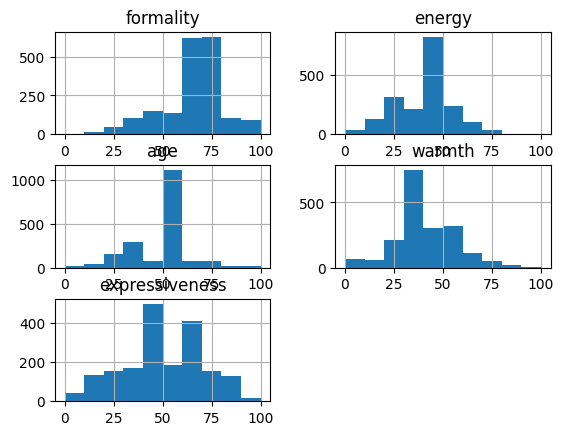

In [8]:
semantic_scores.hist()

In [9]:
proj_dir = os.path.dirname(os.getcwd())  # Goes up one level to TheFontinator/
save_path = os.path.join(proj_dir, 'backend', 'data', 'semantic_axes.parquet')
semantic_scores.to_parquet(save_path, index=True)
